In [1]:
import torch
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tqdm import trange

#64-bit double precision
torch.set_default_dtype(torch.float64) 

## **Learning Equivalence**

How do Backpropogation and Predictive Coding compare on learning to classify handwritten digits?

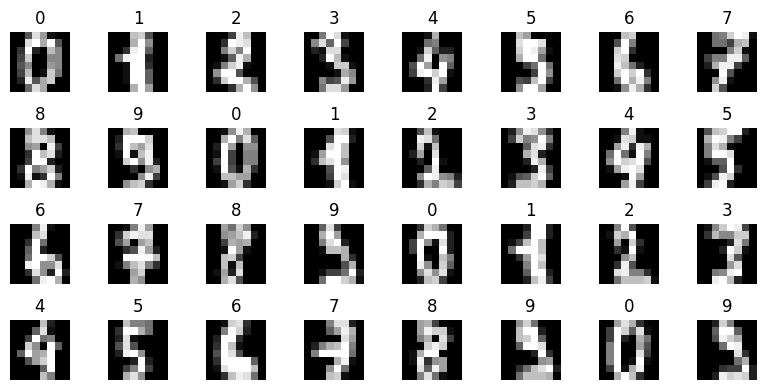

In [2]:
#Setup Dataset
#==========================================
digits = load_digits()
X, y = digits.data, digits.target

#Preview
fig, axes = plt.subplots(4, 8, figsize=(8,4))

for i, ax in enumerate(axes.flat):
    ax.imshow(X[i].reshape(8,8), cmap="gray")
    ax.set_title(y[i])
    ax.axis("off")

plt.tight_layout()
plt.show()

### Train Loop

In [3]:
#Train-Test split
X = StandardScaler().fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train = torch.tensor(X_train, dtype=torch.float64)
y_train = torch.tensor(y_train, dtype=torch.long)
X_test = torch.tensor(X_test, dtype=torch.float64)
y_test = torch.tensor(y_test, dtype=torch.long)

y_train_onehot = torch.nn.functional.one_hot(y_train, num_classes=10).to(torch.float64)
y_test_onehot = torch.nn.functional.one_hot(y_test, num_classes=10).to(torch.float64)

In [4]:
#Initialize Two Identical Networks
#==========================================
torch.manual_seed(42)
input_size, hidden_size, output_size = 64, 64, 10

W1_init = torch.randn(hidden_size, input_size) * 0.1
W2_init = torch.randn(output_size, hidden_size) * 0.1

W1_bp = W1_init.clone().requires_grad_(True)
W2_bp = W2_init.clone().requires_grad_(True)

W1_pc = W1_init.clone().requires_grad_(True)
W2_pc = W2_init.clone().requires_grad_(True)

lr = 0.05
opt_bp = optim.SGD([W1_bp, W2_bp], lr=lr)
opt_pc = optim.SGD([W1_pc, W2_pc], lr=lr)


#Training Loop: Train one network with BP and another with PC
#==========================================
epochs = 50
batch_size = 64

bp_losses, pc_losses = [], []
bp_accs, pc_accs = [], []

gamma = 0.001

print("training.")

for epoch in trange(epochs):
    permutation = torch.randperm(X_train.size()[0])
    epoch_bp_loss, epoch_pc_loss = 0.0, 0.0
    
    for i in range(0, X_train.size()[0], batch_size):
        indices = permutation[i:i+batch_size]
        batch_x, batch_y = X_train[indices], y_train_onehot[indices]
        
        #-----------------------------------
        #BP update
        opt_bp.zero_grad()
        v1_bp = torch.relu(batch_x @ W1_bp.T)
        v2_bp = v1_bp @ W2_bp.T
        
        loss_bp = 0.5 * torch.sum((v2_bp - batch_y)**2) / batch_size
        loss_bp.backward()
        opt_bp.step()
        epoch_bp_loss += loss_bp.item()
        
        #-----------------------------------
        #PC update
        with torch.no_grad():
            v1_hat_init = torch.relu(batch_x @ W1_pc.T)
            
        v1_pc = v1_hat_init.clone().requires_grad_(True)
        v_optim = optim.SGD([v1_pc], lr=0.5) 
        
        #1.Inference
        for _ in range(5):
            v_optim.zero_grad()
            
            v1_hat = torch.relu(batch_x @ W1_pc.T)
            v2_hat = v1_pc @ W2_pc.T
            
            e1 = v1_pc - v1_hat
            e2 = batch_y - v2_hat 
            
            F_inf = 0.5 * torch.sum(e1**2) + gamma * 0.5 * torch.sum(e2**2)
            F_inf.backward()
            v_optim.step()
            
        #2.Weight Update
        opt_pc.zero_grad()
        
        v1_hat = torch.relu(batch_x @ W1_pc.T)
        v2_hat = v1_pc @ W2_pc.T
        
        e1 = v1_pc - v1_hat
        e2 = batch_y - v2_hat
        
        final_F = (0.5 * torch.sum(e1**2) + gamma * 0.5 * torch.sum(e2**2)) / batch_size
        final_F.backward()
        
        W1_pc.grad /= gamma
        W2_pc.grad /= gamma
        
        opt_pc.step()
        
        #Record Task Loss
        with torch.no_grad():
            ff_out = torch.relu(batch_x @ W1_pc.T) @ W2_pc.T
            true_pc_loss = 0.5 * torch.sum((ff_out - batch_y)**2) / batch_size
        epoch_pc_loss += true_pc_loss.item()

    #Performance
    with torch.no_grad():
        out_bp = torch.relu(X_test @ W1_bp.T) @ W2_bp.T
        bp_acc = (out_bp.argmax(dim=1) == y_test).float().mean().item()
        
        out_pc = torch.relu(X_test @ W1_pc.T) @ W2_pc.T
        pc_acc = (out_pc.argmax(dim=1) == y_test).float().mean().item()
        
    bp_losses.append(epoch_bp_loss / (X_train.size()[0] / batch_size))
    pc_losses.append(epoch_pc_loss / (X_train.size()[0] / batch_size))
    bp_accs.append(bp_acc)
    pc_accs.append(pc_acc)


training.


100%|██████████| 50/50 [00:01<00:00, 28.75it/s]


#### Loss Curves

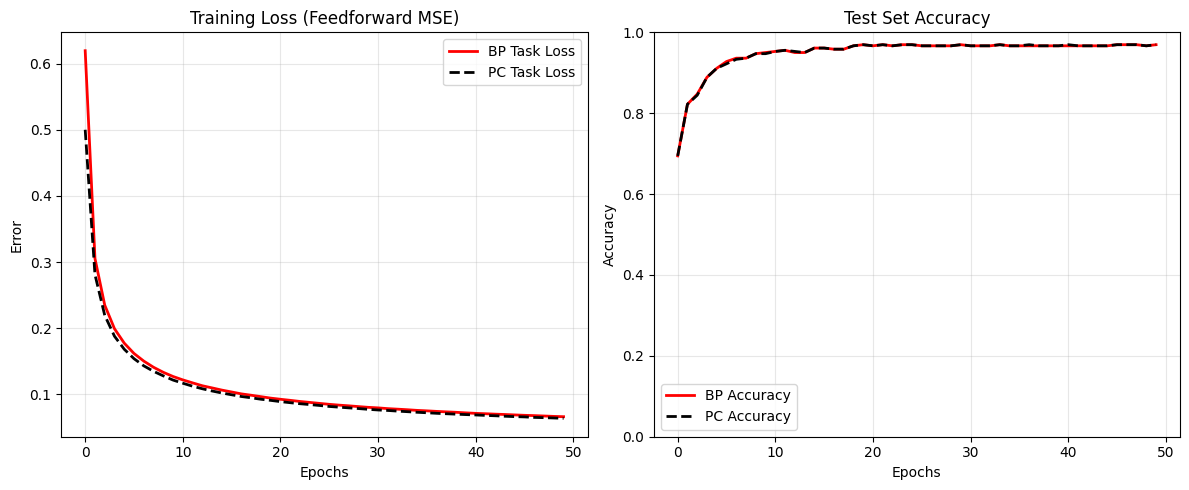

In [5]:
#Plot
#==========================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(bp_losses, label="BP Task Loss", color='red', linewidth=2)
ax1.plot(pc_losses, label="PC Task Loss", color='black', linestyle='--', linewidth=2)
ax1.set_title("Training Loss (Feedforward MSE)")
ax1.set_xlabel("Epochs")
ax1.set_ylabel("Error")
ax1.grid(True, alpha=0.3)
ax1.legend()

ax2.plot(bp_accs, label="BP Accuracy", color='red', linewidth=2)
ax2.plot(pc_accs, label="PC Accuracy", color='black', linestyle='--', linewidth=2)
ax2.set_title("Test Set Accuracy")
ax2.set_xlabel("Epochs")
ax2.set_ylabel("Accuracy")
ax2.set_ylim(0, 1.0)
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

In [17]:
print("Similarity of weights: (Cosine similarity)")
print(f"In layer 1: {torch.inner(W1_pc.ravel(), W1_bp.ravel())/ (torch.linalg.norm(W1_bp)*torch.linalg.norm(W1_pc))}")
print(f"In layer 2: {torch.inner(W2_pc.ravel(), W2_bp.ravel())/ (torch.linalg.norm(W2_bp)*torch.linalg.norm(W2_pc))}", end="\n \n")

print("Final Trained accuracies:")
print(f"Backpropogation:   {bp_accs[-1]}")
print(f"Predictive Coding: {pc_accs[-1]}")

Similarity of weights: (Cosine similarity)
In layer 1: 0.999919839291491
In layer 2: 0.9998616999524746
 
Final Trained accuracies:
Backpropogation:   0.9694444537162781
Predictive Coding: 0.9694444537162781


Notably,
- the learning curves of BP and PC are very similar across epochs.
- the learned weights are the same in both the networks, and so is the final accuracy of classification.